# Customer Churn Prediction

This project builds machine learning models to predict whether a customer will churn based on demographic, billing, and service usage data.

Models compared:
- Logistic Regression
- Support Vector Machine
- Random Forest

The goal is to identify the most accurate model and understand which features contribute most to churn.



## Dataset

The dataset contains 1000 customer records with the following features:
- CustomerID
- Age
- Gender
- Tenure
- Monthly Charges
- Total Charges
- Contract Type
- Tech Support
- Internet Service
- Churn (Target variable)


#Data Loading
Import necessary libraries



In [ ]:
import pandas as pd


Display dataset

In [ ]:
churn = pd.read_csv("/content/customer_churn_data.csv")
churn

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,4,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes
4,5,42,Male,32,69.01,Month-to-Month,NaN,2208.32,No,Yes
...,...,...,...,...,...,...,...,...,...,...
995,996,42,Male,41,37.14,Month-to-Month,Fiber Optic,1522.74,Yes,Yes
996,997,62,Male,9,80.93,Month-to-Month,NaN,728.37,No,Yes
997,998,51,Female,15,111.72,Month-to-Month,Fiber Optic,1675.80,Yes,Yes
998,999,39,Male,68,65.67,One-Year,NaN,4465.56,No,Yes


#Exploratory Data Analysis
Display info about dataset.

In [ ]:
churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       1000 non-null   int64  
 1   Age              1000 non-null   int64  
 2   Gender           1000 non-null   object 
 3   Tenure           1000 non-null   int64  
 4   MonthlyCharges   1000 non-null   float64
 5   ContractType     1000 non-null   object 
 6   InternetService  703 non-null    object 
 7   TotalCharges     1000 non-null   float64
 8   TechSupport      1000 non-null   object 
 9   Churn            1000 non-null   object 
dtypes: float64(2), int64(3), object(5)
memory usage: 78.3+ KB


There are clearly null values in the InternetService column. Find out how many there are.

In [ ]:
churn.isna().sum().sum()

np.int64(297)

There are 297 values. Fill them with quotation marks.

In [ ]:
churn["InternetService"] = churn["InternetService"].fillna("")


Check for null values now.

In [ ]:
churn.isna().sum().sum()

np.int64(0)

There aren't any. Check for duplicates now.

In [ ]:
churn.duplicated().sum()

np.int64(0)

No duplicates present. Find summary statistics.

In [ ]:
churn.describe()

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,500.500000,44.674000,18.97300,74.391290,1404.364060
std,288.819436,9.797741,18.89257,25.712083,1571.755048
min,1.000000,12.000000,0.00000,30.000000,0.000000
25%,250.750000,38.000000,5.00000,52.357500,345.217500
50%,500.500000,45.000000,13.00000,74.060000,872.870000
75%,750.250000,51.000000,26.00000,96.102500,1900.175000
max,1000.000000,83.000000,122.00000,119.960000,12416.250000


Create the correlation matrix.

In [ ]:
numeric_columns_data = churn.select_dtypes(include = ["number"])
numeric_columns_data.corr()


,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
CustomerID,1.000000,0.036730,-0.018585,-0.030504,-0.027490
Age,0.036730,1.000000,0.000472,0.006362,-0.001896
Tenure,-0.018585,0.000472,1.000000,-0.014552,0.894868
MonthlyCharges,-0.030504,0.006362,-0.014552,1.000000,0.304893
TotalCharges,-0.027490,-0.001896,0.894868,0.304893,1.000000


Find class distribution.

In [ ]:
churn["Churn"].value_counts()

,count
Churn,
Yes,883
No,117


Churning customers massively outnumber non-churning customers. Let's find the average monthly charge per class of customer.

In [ ]:
churn.groupby("Churn")["MonthlyCharges"].mean()

,MonthlyCharges
Churn,
No,62.54641
Yes,75.96077


Churning customers on average have more in charges than non-churning customers. Find the average charge by class and gender of customer.

In [ ]:
churn.groupby(["Churn","Gender"])["MonthlyCharges"].mean()

Churn  Gender
No     Female    65.091912
       Male      59.013878
Yes    Female    74.975064
       Male      77.082518
Name: MonthlyCharges, dtype: float64

There is some difference in gender; female non-churners are charged more than male non-churners. The trend is the opposite for churners. Find the average tenure per class.

In [ ]:
churn.groupby("Churn")["Tenure"].mean()

,Tenure
Churn,
No,30.264957
Yes,17.476784


Churners on average have a lower tenure. Find average age per class.

In [ ]:
churn.groupby("Churn")["Age"].mean()

,Age
Churn,
No,43.487179
Yes,44.831257


No real difference based on age. Find average monthly charges per contract type.

In [ ]:
churn.groupby("ContractType")["MonthlyCharges"].mean()

,MonthlyCharges
ContractType,
Month-to-Month,75.909198
One-Year,73.822803
Two-Year,71.334500


Hardly any difference by contract type. Plot histogram of monthly charges.

Text(0, 0.5, 'Frequency')

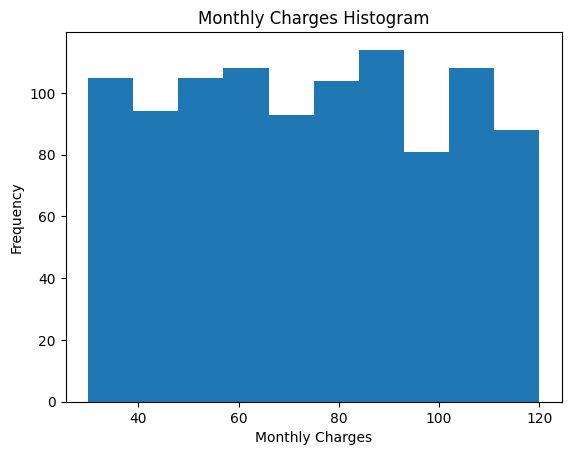

In [ ]:
import matplotlib.pyplot as plt
plt.hist(churn["MonthlyCharges"])
plt.title("Monthly Charges Histogram")
plt.xlabel("Monthly Charges")
plt.ylabel("Frequency")

The distribution is very uniform. Let's do the same for tenure.

Text(0, 0.5, 'Frequency')

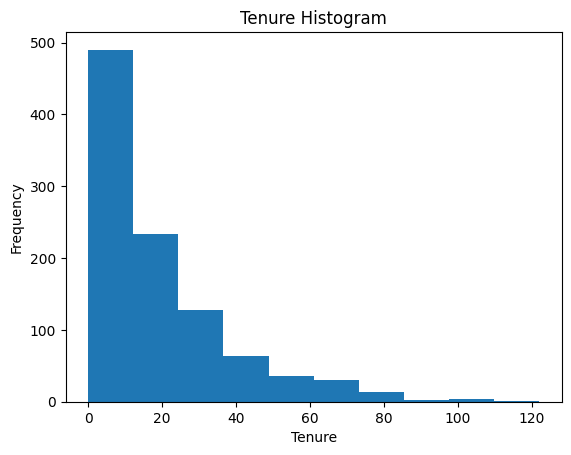

In [ ]:
plt.hist(churn["Tenure"])
plt.title("Tenure Histogram")
plt.xlabel("Tenure")
plt.ylabel("Frequency")


There is a sharp right skew, indicating that the bulk of all customers have not been around for very long. Analyze relationship between tech support and customer churn status.

In [ ]:
Table = pd.crosstab(churn["TechSupport"],churn["Churn"])
Table

Churn,No,Yes
TechSupport,,
No,0,494
Yes,117,389


Based on this, all of the customers who didn't see tech support churned while results are much more split for those who did.

#Data Preparation

Split the dataset now.

In [ ]:
y = churn["Churn"]
X = churn.drop(columns = ["Churn","CustomerID","InternetService"])

In [ ]:
X

,Age,Gender,Tenure,MonthlyCharges,ContractType,TotalCharges,TechSupport
0,49,Male,4,88.35,Month-to-Month,353.40,Yes
1,43,Male,0,36.67,Month-to-Month,0.00,Yes
2,51,Female,2,63.79,Month-to-Month,127.58,No
3,60,Female,8,102.34,One-Year,818.72,Yes
4,42,Male,32,69.01,Month-to-Month,2208.32,No
...,...,...,...,...,...,...,...
995,42,Male,41,37.14,Month-to-Month,1522.74,Yes
996,62,Male,9,80.93,Month-to-Month,728.37,No
997,51,Female,15,111.72,Month-to-Month,1675.80,Yes
998,39,Male,68,65.67,One-Year,4465.56,No


One hot encode all the categorical columns in X.

In [ ]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# Find categorical columns
categorical_columns = X.select_dtypes(include=['object']).columns

# Create encoder
encoder = OneHotEncoder(sparse_output=False, drop='first')

# Fit and transform
encoded = encoder.fit_transform(X[categorical_columns])

# Convert to DataFrame
encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(categorical_columns),
    index=X.index
)

# Drop original categorical columns
X = X.drop(columns=categorical_columns)

# Concatenate encoded columns
X = pd.concat([X, encoded_df], axis=1)

# View result
X.head()

,Age,Tenure,MonthlyCharges,TotalCharges,Gender_Male,ContractType_One-Year,ContractType_Two-Year,TechSupport_Yes
0,49,4,88.35,353.40,1.0,0.0,0.0,1.0
1,43,0,36.67,0.00,1.0,0.0,0.0,1.0
2,51,2,63.79,127.58,0.0,0.0,0.0,0.0
3,60,8,102.34,818.72,0.0,1.0,0.0,1.0
4,42,32,69.01,2208.32,1.0,0.0,0.0,0.0


Prepare for modeling.

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify = y, test_size=0.2, random_state=42)

# Model Training and Evaluation

Run a Logistic Regression, Support Vector Machine, and Random Forest model on the dataset to predict churn status.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
lr = LogisticRegression(class_weight='balanced')
svm = SVC(class_weight='balanced')
rf = RandomForestClassifier(class_weight = 'balanced')
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
lr.fit(X_train_scaled, y_train)
svm.fit(X_train_scaled, y_train)
rf.fit(X_train, y_train)
from sklearn.metrics import accuracy_score, classification_report
y_pred_lr = lr.predict(X_test_scaled)
y_pred_svm = svm.predict(X_test_scaled)
y_pred_rf = rf.predict(X_test)
print("Logistic Regression:")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression:
Accuracy: 0.94
              precision    recall  f1-score   support

          No       0.66      1.00      0.79        23
         Yes       1.00      0.93      0.96       177

    accuracy                           0.94       200
   macro avg       0.83      0.97      0.88       200
weighted avg       0.96      0.94      0.95       200



In [ ]:
print("Support Vector Classifier:")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

Support Vector Classifier:
Accuracy: 0.97
              precision    recall  f1-score   support

          No       0.79      1.00      0.88        23
         Yes       1.00      0.97      0.98       177

    accuracy                           0.97       200
   macro avg       0.90      0.98      0.93       200
weighted avg       0.98      0.97      0.97       200



In [ ]:
print("Random Forest:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest:
Accuracy: 0.995
              precision    recall  f1-score   support

          No       1.00      0.96      0.98        23
         Yes       0.99      1.00      1.00       177

    accuracy                           0.99       200
   macro avg       1.00      0.98      0.99       200
weighted avg       1.00      0.99      0.99       200




# Results and Analysis

Based on all this, all models did very well at predicting the churning class (not a surprise since it is the overwhelming majority). Random Forest did best overall at distinguishing between the two classes as evident by the perfect or almost perfect f1 scores for both classes while the other two models had a significant tendency of predicting churn when there wasn't any. Let's do feature importance now to see which features contributed the most to model performance.

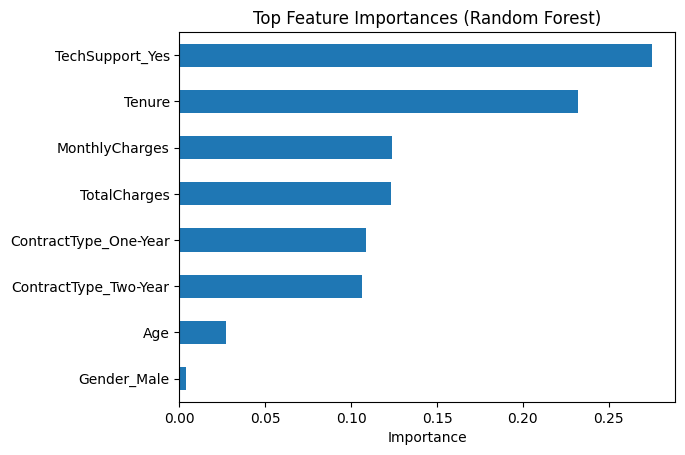

In [ ]:
importances = rf.feature_importances_
feature_importance = pd.Series(importances, index=X.columns)
feature_importance.sort_values(ascending=True).tail(10).plot(kind='barh')
plt.title("Top Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.show()


Based on this, it is evident that tech support utilization is the most strongly predictive of churn status followed by customer tenure and montly charges. Demographic categories like age and gender were the least important. This isn't a complete surprise since all customers who did not see tech support churned while a substantially large minority of those who did remained with the company. Also, the average tenure for churners was much lower than for non-churners and the average monthly charge was higher for churners. In other words, the exploratory data analysis that was done prior to modeling supports the feature importance finding.



#Conclusion
Overall, the ensemble tree model known as Random Forest did the best job of predicting whether customers would churn. Based on the feature importance plot, it is evident that factors such as the use of tech support, length of customer tenure, and monthly charges are the most correlated with churn status, much more so than demographic categories such as age or gender. This strongly suggests that in order to avoid churn, businesses need to be more vigilant about ensuring that customers can easily access tech support, keep them engaged in the long run, and prevent charges from getting very high. Following through with these steps is sure to increase company profitability.